# LeetCode #100: Same Tree

https://leetcode.com/problems/same-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Serialize and compare | O(n) | O(n) | Serialize both to strings, compare |
| **DFS Recursive ★** | **O(n)** | **O(n)** | Check null/value at each node, recurse left and right |
| BFS level-order | O(n) | O(n) | Compare level by level with queue |

---

## Understanding the Methods

### Brute Force (Serialize)
Serialize both trees to strings (e.g., preorder with null markers) and compare. Works but overhead of string building.

### Optimal: DFS Recursive ★
Three conditions at every node pair:
1. Both null → true (matching empty subtrees).
2. Exactly one null → false (structure mismatch).
3. Values differ → false.
4. Otherwise → recurse on both left and right.

Short-circuit evaluation means mismatches are detected as soon as found — no need to traverse the whole tree.

**Constraints:**
* Number of nodes: [0, 100] per tree
* Node values: [-10^4, 10^4]

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsSameTree(TreeNode p, TreeNode q) {
        if (p == null && q == null) return true;
        if (p == null || q == null) return false;
        if (p.val != q.val)         return false;
        return IsSameTree(p.left,  q.left) &&
               IsSameTree(p.right, q.right);
    }
}

### Python

In [ ]:
class Solution:
    def isSameTree(self, p, q) -> bool:
        if not p and not q:
            return True
        if not p or not q:
            return False
        if p.val != q.val:
            return False
        return self.isSameTree(p.left, q.left) and                self.isSameTree(p.right, q.right)

### Go

In [ ]:
func isSameTree(p *TreeNode, q *TreeNode) bool {
    if p == nil && q == nil {
        return true
    }
    if p == nil || q == nil {
        return false
    }
    if p.Val != q.Val {
        return false
    }
    return isSameTree(p.Left, q.Left) && isSameTree(p.Right, q.Right)
}

### Rust

In [ ]:
impl Solution {
    pub fn is_same_tree(
        p: Option<Rc<RefCell<TreeNode>>>,
        q: Option<Rc<RefCell<TreeNode>>>,
    ) -> bool {
        match (p, q) {
            (None, None) => true,
            (None, _) | (_, None) => false,
            (Some(pn), Some(qn)) => {
                if pn.borrow().val != qn.borrow().val { return false; }
                Self::is_same_tree(pn.borrow().left.clone(), qn.borrow().left.clone()) &&
                Self::is_same_tree(pn.borrow().right.clone(), qn.borrow().right.clone())
            }
        }
    }
}

## Example Scenarios

### 1. Common Case — Identical Trees
**Input:** `p = [1, 2, 3]`, `q = [1, 2, 3]`

Compare root: $1 = 1$. Left: $2 = 2$. Right: $3 = 3$. All null children match. Every node pair passes the value and structure check.

*Why tricky:* Straightforward happy path verifying both value equality and structural equality at every node pair.

$n = 3$ per tree. $2n + 1 = 7$ recursive calls. $O(n)$ time, $O(h) = O(2)$ stack.

**Output:** `true`

---

### 2. Slightly Complex — Same Values, Different Structure
**Input:** `p = [1, 2]`, `q = [1, null, 2]`

Root: $1 = 1$. Left: p has node(2), q has null → one null, one not → false! Same set of values $\{1,2\}$ but placed in different positions.

*Why tricky:* Tests that structure, not just values, must match. A common mistake is comparing only value sets or only one subtree.

Short-circuits after 2 comparisons: root match, then left mismatch. $O(1)$ effective time.

**Output:** `false`

---

### 3. Edge Case: Time Factor — Two Identical 100-Node Trees
**Input:** `p = q =` balanced tree of 100 nodes

No early exit — every node matches, so full DFS visits all 100 node pairs plus null leaf pairs. Worst case for time when the answer is true.

*Why tricky:* Maximum $n = 100$ with no short-circuit. Must visit all $2n + 1 = 201$ call sites to confirm equality.

$n = 100$. Height $\approx \lfloor \log_2 100 \rfloor = 7$. Stack depth $= O(7)$.

**Output:** `true`

---

### 4. Edge Case: Space Factor — Two Identical Left-Skewed Chains
**Input:** `p = q =` left-skewed chain of 100 nodes

Both trees: $100 \to 99 \to \ldots \to 1$ (all left children). DFS goes 100 levels deep. Stack space $= O(n)$, worst case. All nodes match so full traversal required.

*Why tricky:* Worst-case stack depth $= n = 100$. Identical trees + max depth means no short-circuit and maximum recursion.

Stack depth $= n = 100 = O(n)$. Total calls: $100 + 101 = 201$.

**Output:** `true`

---

### 5. Almost-Impossible but Plausible — Differ at Deepest Leaf, Boundary Values
**Input:** `p =` perfect tree depth 6 (63 nodes, all val $= 10000$). `q =` identical except one leaf has val $= -10000$.

DFS matches 62 node pairs before reaching the single differing leaf at maximum depth. Mismatch: $10000 \neq -10000$. Worst-case position for detection.

*Why tricky:* Near-miss at boundary values ($10000$ vs $-10000$, constraint limits). DFS visits almost the entire tree before detecting the difference.

$n = 63 = 2^6 - 1$. Mismatch at the $63^{\text{rd}}$ comparison. $|10000 - (-10000)| = 20{,}000$.

**Output:** `false`

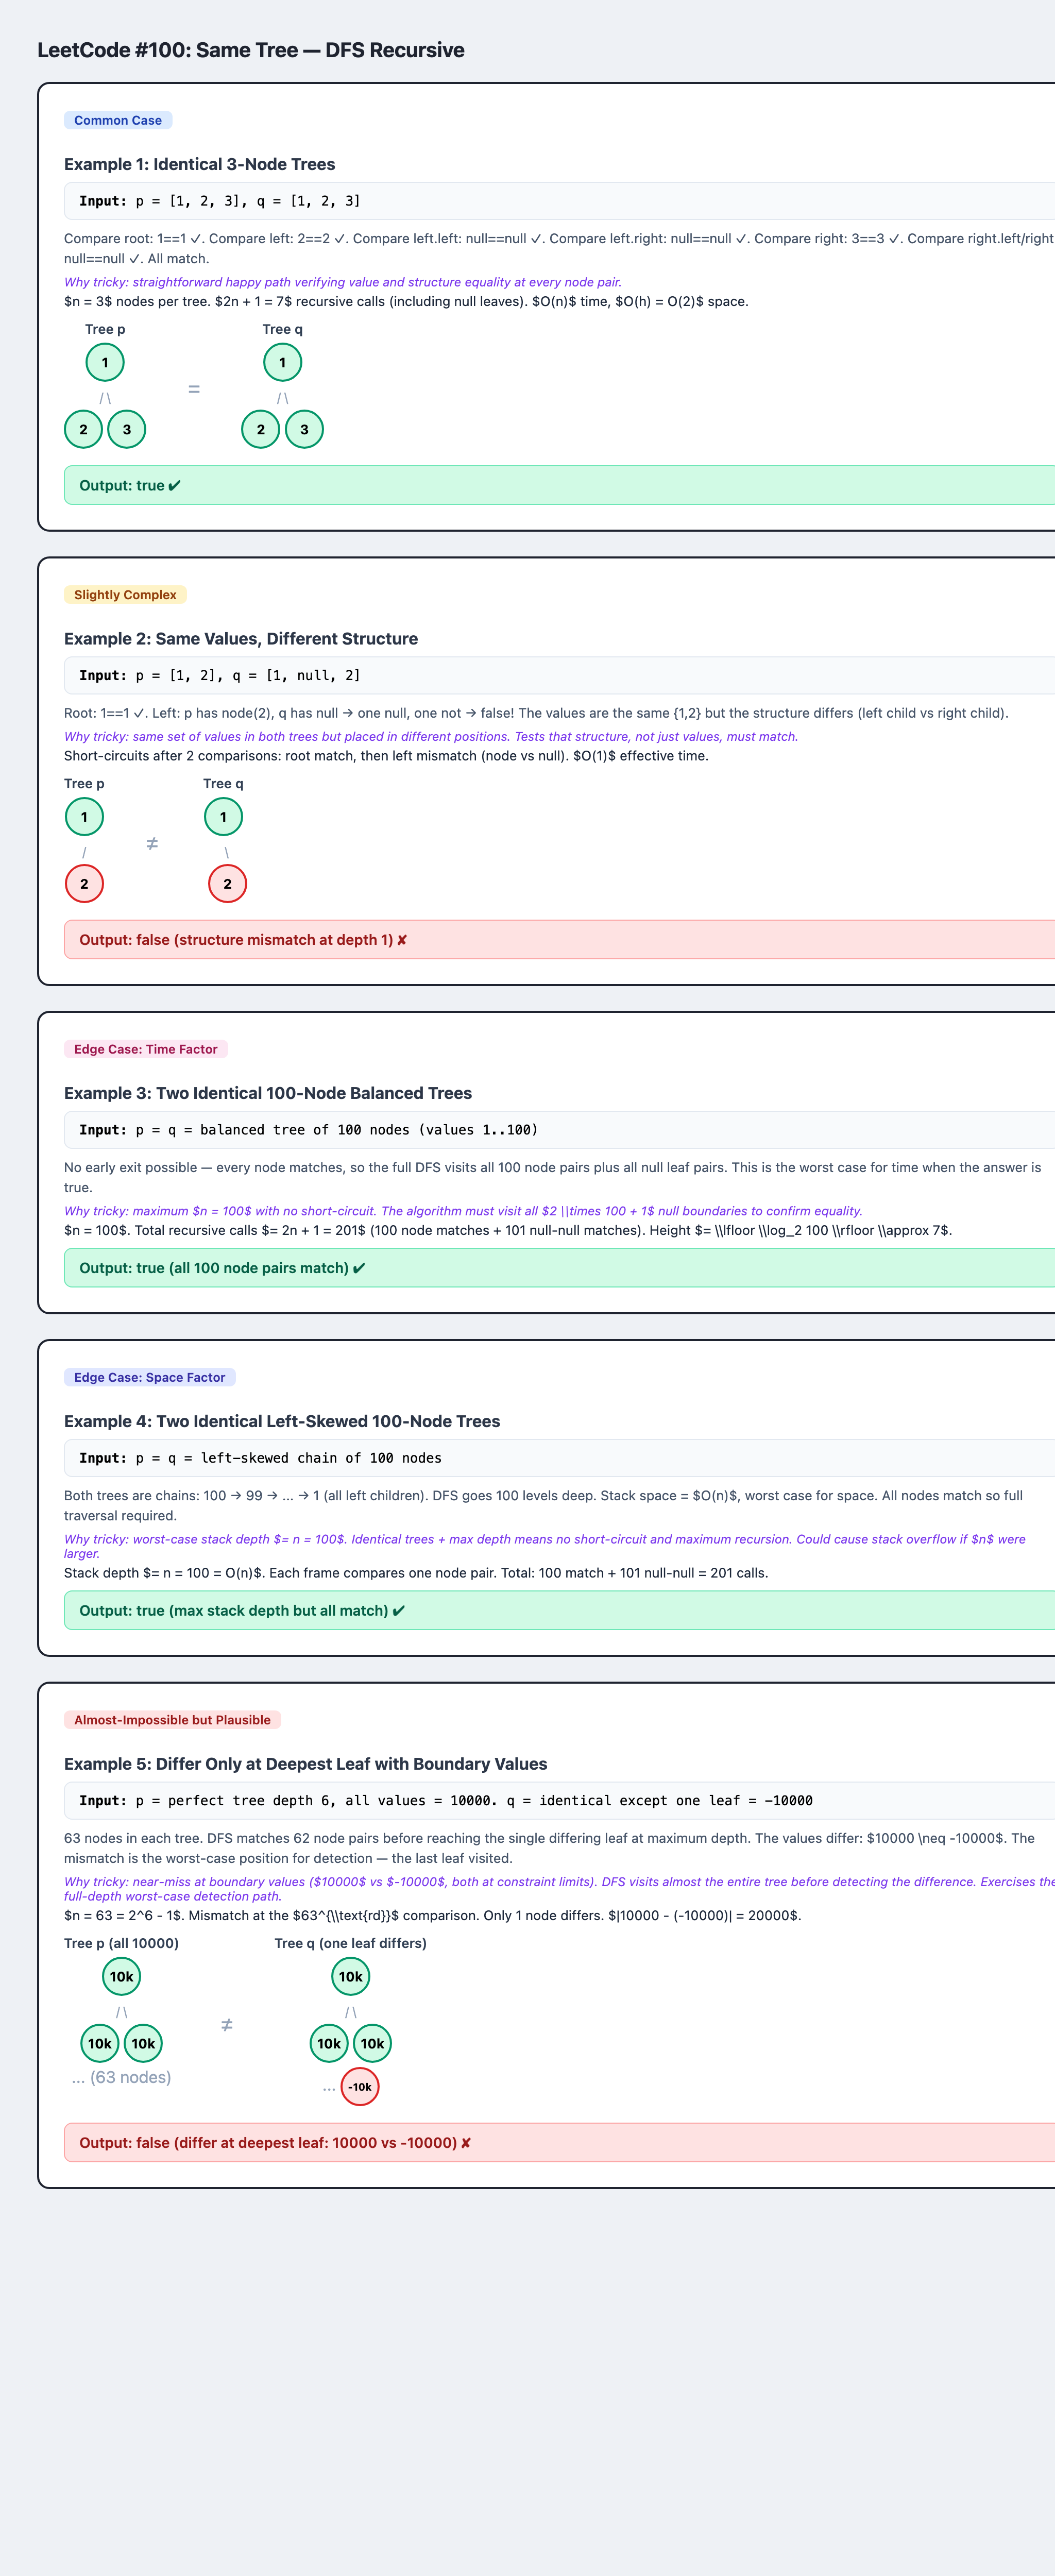